In [3]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


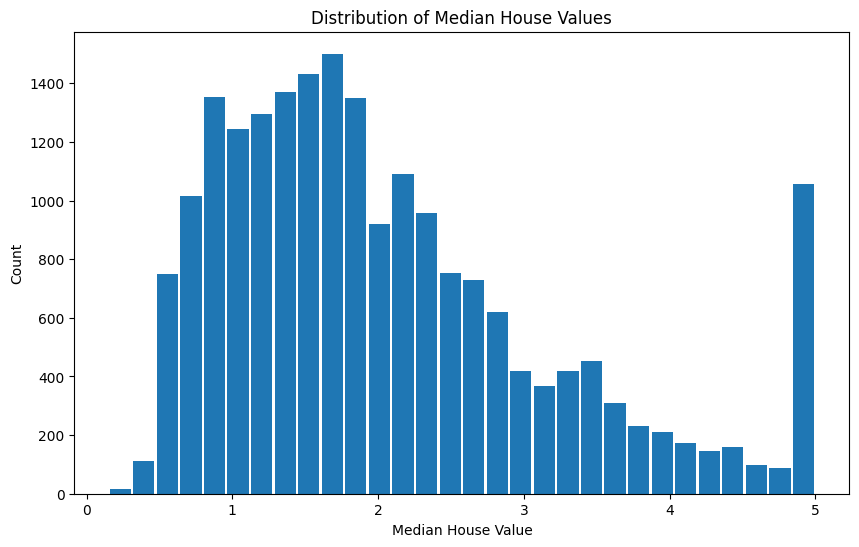

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df["MedHouseVal"], bins=30, rwidth=0.9)
plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

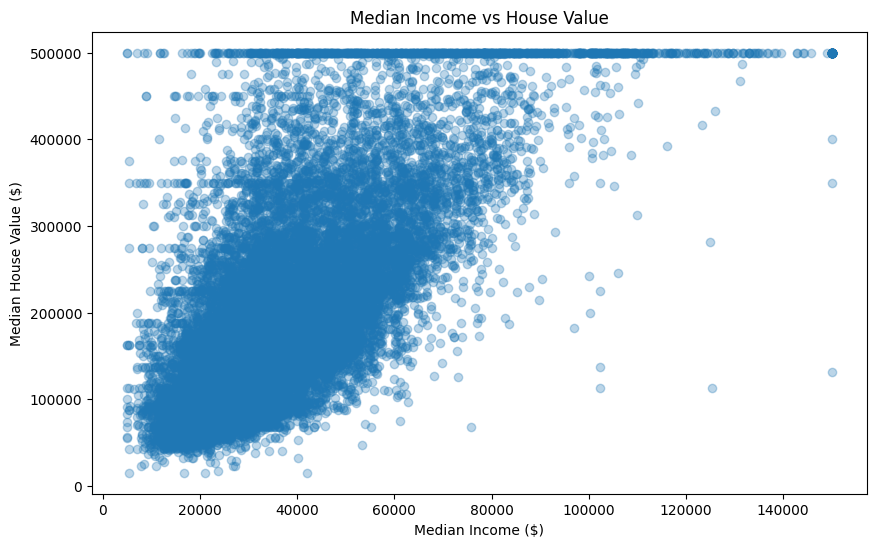

In [8]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["MedInc"] * 10000,
    df["MedHouseVal"] * 100000,
    alpha=0.3
)

plt.title("Median Income vs House Value")
plt.xlabel("Median Income ($)")
plt.ylabel("Median House Value ($)")
plt.show()

In [9]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [10]:
df["MedInc_real"] = df["MedInc"] * 10000
df["MedHouseVal_real"] = df["MedHouseVal"] * 100000

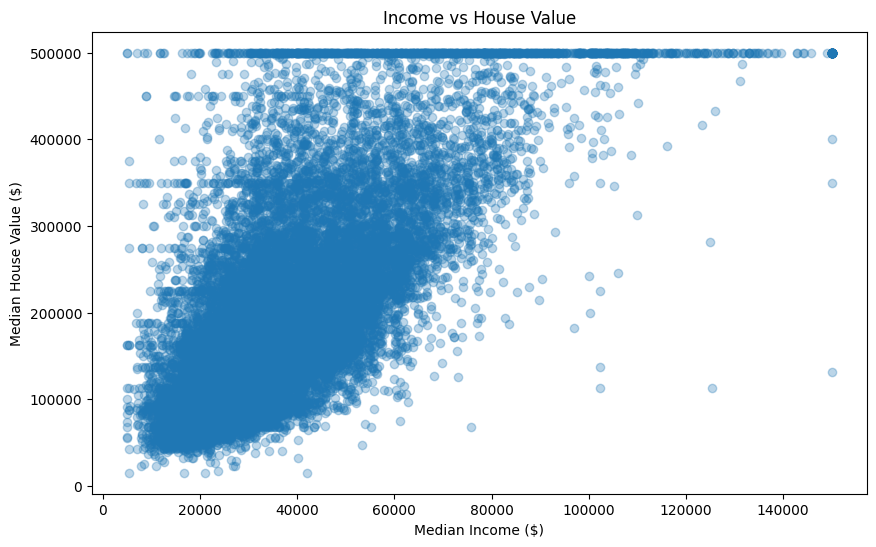

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["MedInc_real"],
    df["MedHouseVal_real"],
    alpha=0.3
)

plt.title("Income vs House Value")
plt.xlabel("Median Income ($)")
plt.ylabel("Median House Value ($)")
plt.show()

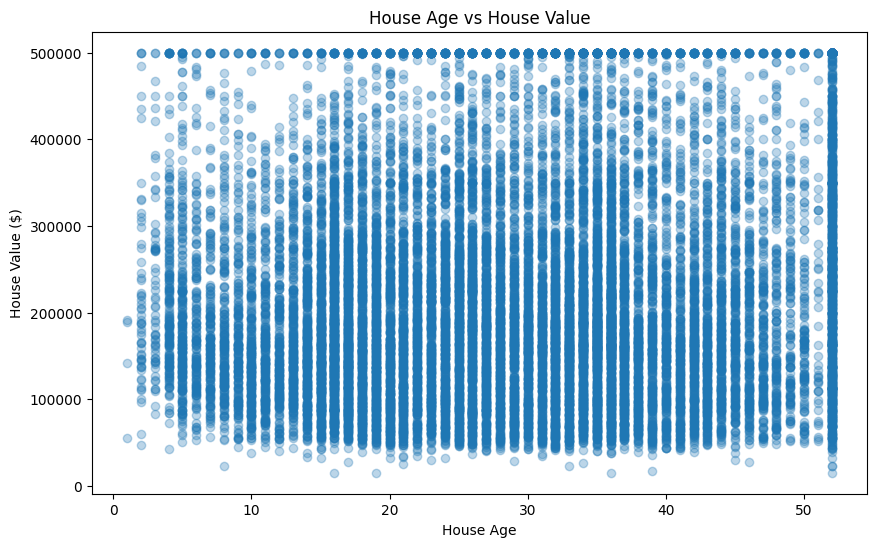

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["HouseAge"],
    df["MedHouseVal_real"],
    alpha=0.3
)

plt.title("House Age vs House Value")
plt.xlabel("House Age")
plt.ylabel("House Value ($)")
plt.show()

In [13]:
print("Average House Value:", df["MedHouseVal_real"].mean())
print("Average Income:", df["MedInc_real"].mean())
print("Average House Age:", df["HouseAge"].mean())
print("Total Regions:", len(df))

Average House Value: 206855.81690891474
Average Income: 38706.71002906977
Average House Age: 28.639486434108527
Total Regions: 20640


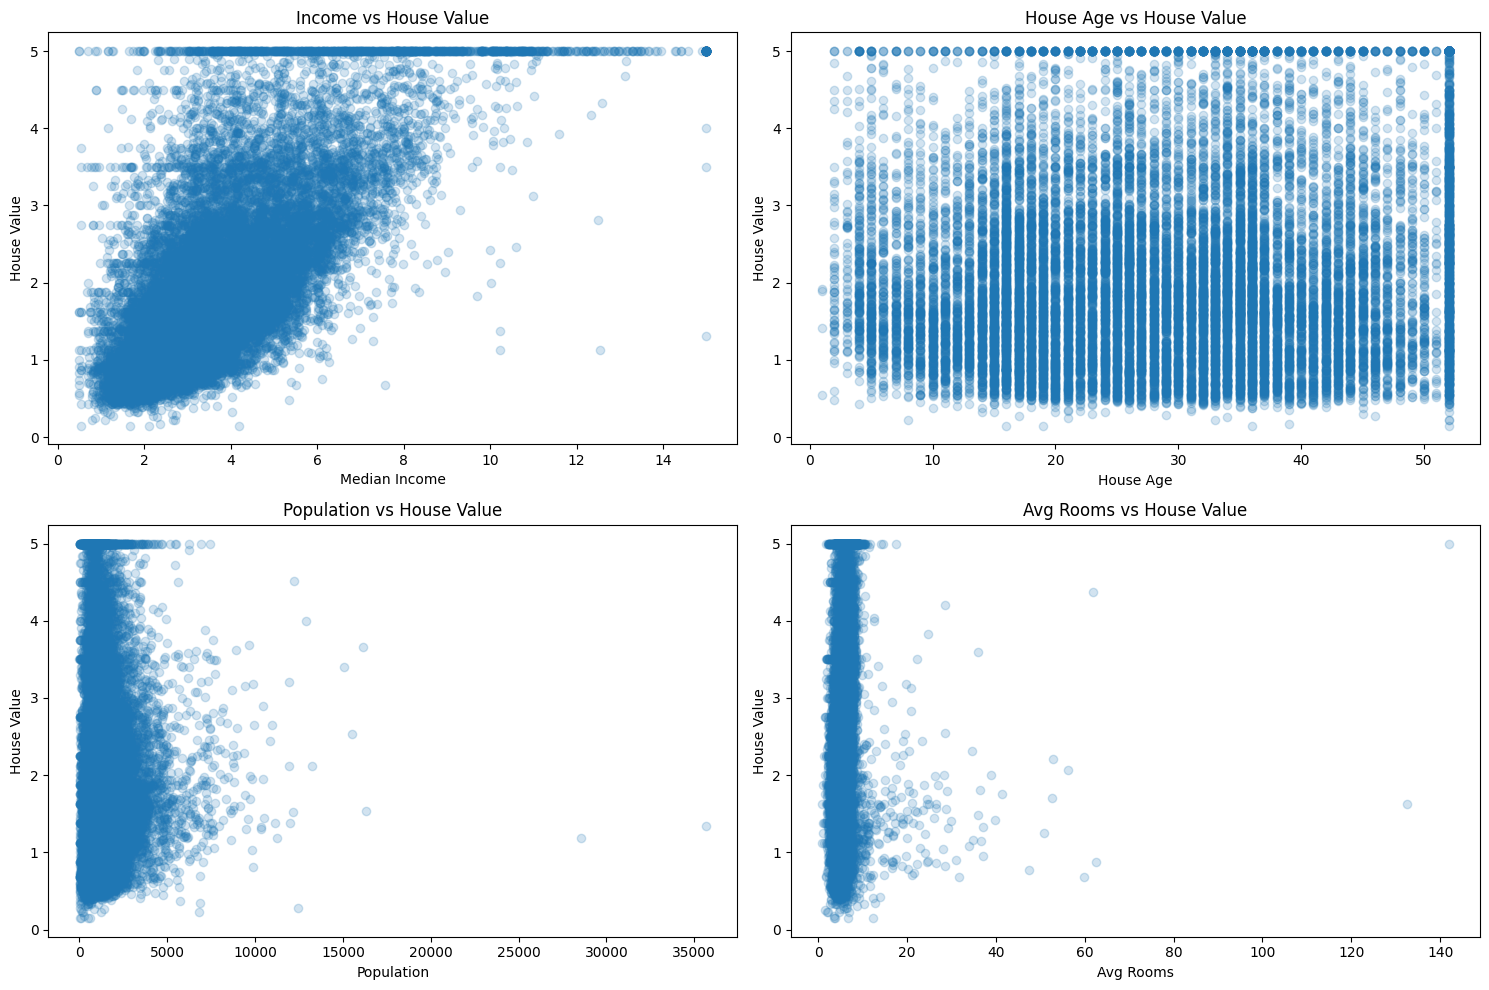

<Figure size 640x480 with 0 Axes>

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Income vs House Value
axes[0,0].scatter(df["MedInc"], df["MedHouseVal"], alpha=0.2)
axes[0,0].set_title("Income vs House Value")
axes[0,0].set_xlabel("Median Income")
axes[0,0].set_ylabel("House Value")

# 2. House Age vs House Value
axes[0,1].scatter(df["HouseAge"], df["MedHouseVal"], alpha=0.2)
axes[0,1].set_title("House Age vs House Value")
axes[0,1].set_xlabel("House Age")
axes[0,1].set_ylabel("House Value")

# 3. Population vs House Value
axes[1,0].scatter(df["Population"], df["MedHouseVal"], alpha=0.2)
axes[1,0].set_title("Population vs House Value")
axes[1,0].set_xlabel("Population")
axes[1,0].set_ylabel("House Value")

# 4. Average Rooms vs House Value
axes[1,1].scatter(df["AveRooms"], df["MedHouseVal"], alpha=0.2)
axes[1,1].set_title("Avg Rooms vs House Value")
axes[1,1].set_xlabel("Avg Rooms")
axes[1,1].set_ylabel("House Value")

plt.tight_layout()
plt.show()

plt.savefig("housing_dashboard.png", bbox_inches="tight")
plt.show()

In [15]:
print("INSIGHTS SUMMARY")
print("- Higher income areas tend to have higher house values")
print("- House age has weak/moderate relationship with price")
print("- Population does not strongly predict house value")
print("- Number of rooms shows mild positive correlation")

INSIGHTS SUMMARY
- Higher income areas tend to have higher house values
- House age has weak/moderate relationship with price
- Population does not strongly predict house value
- Number of rooms shows mild positive correlation


In [17]:
fig.savefig("housing_dashboard.png", bbox_inches="tight")

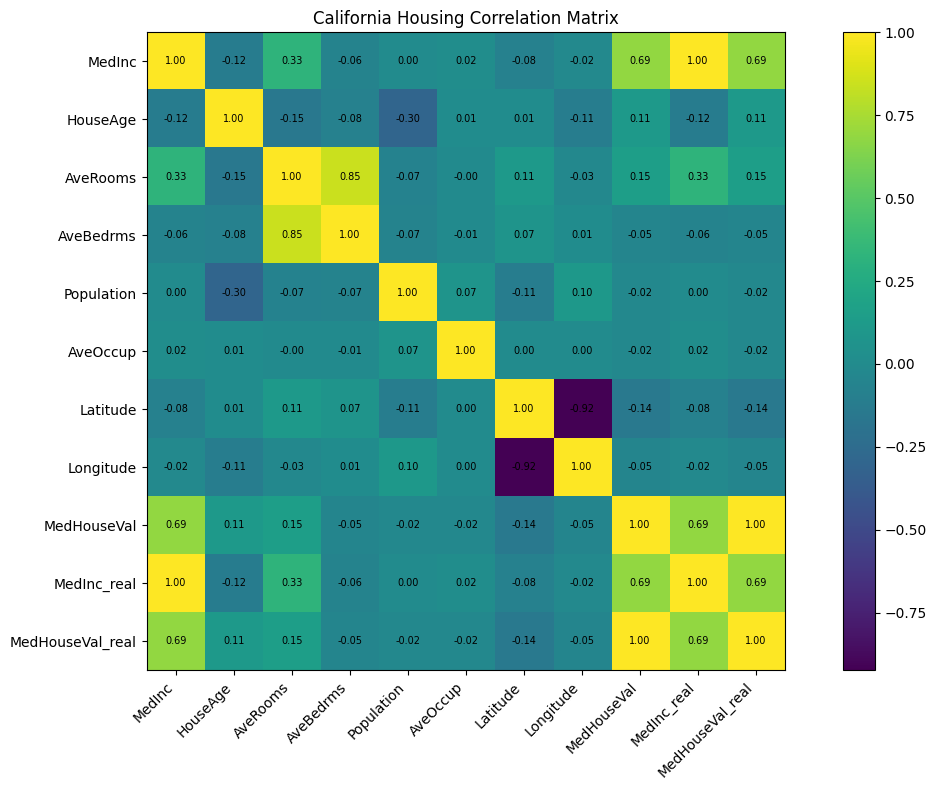

<Figure size 640x480 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

heatmap = plt.imshow(corr_matrix)

plt.colorbar(heatmap)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

# Add correlation values
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.title("California Housing Correlation Matrix")
plt.tight_layout()
plt.show()

plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()